In [2]:
# =========================
# Full self-contained cell
# (includes all helper funcs used)
# =========================

import os
import numpy as np
import trimesh
import matplotlib.pyplot as plt

from shapely.geometry import Polygon, MultiPolygon, LineString
from shapely.ops import unary_union, polygonize
from shapely.geometry.polygon import orient


def iter_polygons(geom):
    """Yield Polygon objects from a Polygon or MultiPolygon."""
    if isinstance(geom, Polygon):
        yield geom
    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            yield g


def _footprint_at_z0(mesh: trimesh.Trimesh, dz_guard: float = 1e-3):
    """
    Return the footprint (Polygon or MultiPolygon, world XY) of 'mesh' at z=0.
    Uses: section() + coplanar triangles. No Rtree required.
    Ensures the mesh straddles z=0 by translating if necessary.
    """
    # 0) Ensure we intersect z=0
    zmin, zmax = mesh.bounds[:, 2]
    if zmin > 0:
        mesh.apply_translation([0, 0, -(zmin + dz_guard)])
    elif zmax < 0:
        mesh.apply_translation([0, 0, -(zmax - dz_guard)])

    # tolerance scaled to model size
    tol = max(1e-7, 1e-7 * float(np.linalg.norm(mesh.extents)))

    # 1) Section curves at (near) z=0
    section = mesh.section(plane_origin=[0, 0, 0], plane_normal=[0, 0, 1])
    if section is None:
        for dz in (tol, -tol, 10 * tol, -10 * tol):
            section = mesh.section(plane_origin=[0, 0, dz], plane_normal=[0, 0, 1])
            if section is not None:
                break

    section_polys_world = []
    if section is not None:
        # Flatten to 2D and get transform back to world
        sec2d, T = section.to_planar()

        # Try polygons_full; fall back to polygonize
        try:
            polys_2d = list(sec2d.polygons_full)
        except ModuleNotFoundError:
            V2 = np.asarray(sec2d.vertices)
            E2 = np.asarray(sec2d.edges)
            lines = [LineString(V2[e]) for e in E2]
            polys_2d = list(polygonize(unary_union(lines)))

        # Map each 2D polygon back to world XY via T
        def poly2d_to_worldXY(p2d):
            def ring_to_worldXY(coords2d):
                P2 = np.asarray(coords2d)
                P3 = np.c_[P2, np.zeros(len(P2))]
                P3w = trimesh.transform_points(P3, T)
                return [(float(x), float(y)) for x, y in P3w[:, :2]]

            ext = ring_to_worldXY(p2d.exterior.coords)
            holes = [ring_to_worldXY(r.coords) for r in p2d.interiors]
            return Polygon(ext, holes)

        section_polys_world = [poly2d_to_worldXY(p) for p in polys_2d if (p is not None and not p.is_empty)]

    # 2) Coplanar triangles at z=0 (area contributions from flat bottoms)
    V3, F = mesh.vertices, mesh.faces
    fz = V3[F][:, :, 2]
    coplanar_mask = (np.abs(fz) < tol).all(axis=1)
    coplanar_polys = []
    if np.any(coplanar_mask):
        tri_xy = V3[F[coplanar_mask]][:, :, :2]
        for tri in tri_xy:
            p = Polygon(tri)
            if p.is_valid and p.area > 0:
                coplanar_polys.append(p)

    # 3) Union all parts -> footprint
    parts = [p for p in (section_polys_world + coplanar_polys) if (p is not None and not p.is_empty)]
    if not parts:
        raise ValueError("No intersection with z=0 found; check mesh pose/scale.")
    footprint = unary_union(parts).buffer(0)

    return footprint  # Polygon or MultiPolygon


def footprint_rings(footprint, ensure_ccw=True, drop_last=True, min_vertices=3):
    """
    Returns a list of dicts, one per polygon piece:
      {
        "exterior": np.ndarray (n,2),
        "holes": [np.ndarray (m_i,2), ...]
      }
    - ensure_ccw: force exterior CCW, holes CW
    - drop_last: Shapely closes rings (first point == last); drop the duplicate
    """
    pieces = []
    for poly in iter_polygons(footprint):
        p = orient(poly, sign=1.0) if ensure_ccw else poly  # exterior CCW
        ext = np.asarray(p.exterior.coords)
        if drop_last:
            ext = ext[:-1]
        if len(ext) < min_vertices:
            continue
        holes = []
        for r in p.interiors:
            h = np.asarray(r.coords)
            if drop_last:
                h = h[:-1]
            if len(h) >= min_vertices:
                holes.append(h)
        pieces.append({"exterior": ext, "holes": holes})
    return pieces


def plot_footprint(geom, title="Footprint @ z=0"):
    """
    Plot a Shapely Polygon/MultiPolygon with holes.
    """
    fig, ax = plt.subplots()

    def _plot_poly(poly: Polygon):
        x, y = poly.exterior.xy
        ax.plot(x, y)
        for ring in poly.interiors:
            hx, hy = ring.xy
            ax.plot(hx, hy)

    if isinstance(geom, Polygon):
        _plot_poly(geom)
    elif isinstance(geom, MultiPolygon):
        for p in geom.geoms:
            _plot_poly(p)
    else:
        raise TypeError(f"Expected Polygon or MultiPolygon, got {type(geom)}")

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    plt.show()
    return fig, ax


def show_footprint(obj_path, scale=0.4, z_shift=-0.005, dz_guard=1e-3):
    """
    Load an OBJ mesh, apply scale+z_shift (same as your ComplexObject),
    compute footprint with _footprint_at_z0, print info, and plot.
    """
    if not os.path.exists(obj_path):
        raise FileNotFoundError(obj_path)

    mesh = trimesh.load(obj_path)
    mesh.apply_scale(scale)
    mesh.apply_translation([0.0, 0.0, float(z_shift)])

    footprint = _footprint_at_z0(mesh.copy(), dz_guard=dz_guard)

    # stats
    if isinstance(footprint, Polygon):
        n_holes = len(footprint.interiors)
    elif isinstance(footprint, MultiPolygon):
        n_holes = sum(len(p.interiors) for p in footprint.geoms)
    else:
        n_holes = 0

    print("Footprint type:", footprint.geom_type)
    print("Area:", float(footprint.area))
    print("Bounds (xmin,ymin,xmax,ymax):", tuple(map(float, footprint.bounds)))
    print("Number of holes:", n_holes)

    # optional: show ring counts
    rings = footprint_rings(footprint)
    print("Pieces:", len(rings))
    for i, piece in enumerate(rings):
        print(f"  piece[{i}] exterior verts={len(piece['exterior'])} holes={len(piece['holes'])}")

    plot_footprint(footprint, title=f"Footprint @ z=0\n{os.path.basename(obj_path)}")
    return footprint





In [4]:
import trimesh
import numpy as np

mesh = trimesh.load("outputs_usability_probability/fused_hpr_poisson.obj", process=False)

zmin = mesh.vertices[:,2].min()
zmax = mesh.vertices[:,2].max()
print("Mesh Z range:", zmin, "to", zmax, "  (span:", zmax-zmin, ")")

Mesh Z range: -0.032161 to 0.571314   (span: 0.603475 )


Footprint type: Polygon
Area: 0.5736095950608441
Bounds (xmin,ymin,xmax,ymax): (-0.3646797370650947, -0.4940243096318129, 0.44716409127541507, 0.47174063252665266)
Number of holes: 0
Pieces: 1
  piece[0] exterior verts=853 holes=0


C:\Users\Priyam Mishra\AppData\Local\Temp\ipykernel_38196\3143366260.py:52: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  sec2d, T = section.to_planar()


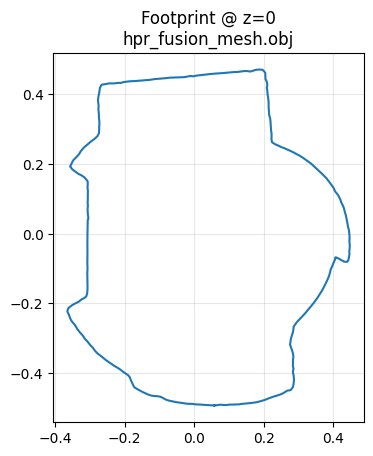

In [9]:
obj_path = "hpr_fusion_mesh.obj"
footprint = show_footprint(obj_path, scale=1, z_shift=-0.05)  # keep your values
footprint = footprint.buffer(0.01).buffer(-0.01)
footprint = footprint.simplify(0.01, preserve_topology=True)

In [12]:
import numpy as np

d = np.load("outputs_usability_probability/clip_pcd_fused_hpr_master.npz")
points = d["points_world"].astype(np.float32)          # (N,3)
usab   = d["usability"].astype(np.int8)          # (N,)
prob   = d["probability"].astype(np.float32)     # (N,)

xy = points[:, :2]  # (N,2)
print("Loaded:", xy.shape, "unique usability:", np.unique(usab))

Loaded: (20040, 2) unique usability: [-1  1]


In [13]:
from shapely.geometry import Polygon, MultiPolygon, LineString

def largest_polygon(geom):
    if isinstance(geom, Polygon):
        return geom
    if isinstance(geom, MultiPolygon):
        return max(list(geom.geoms), key=lambda p: p.area)
    raise TypeError(f"Unsupported type: {type(geom)}")

def sample_boundary(poly: Polygon, n_samples=800):
    boundary = LineString(poly.exterior.coords)
    L = boundary.length
    dists = np.linspace(0.0, L, n_samples, endpoint=False)
    pts = [boundary.interpolate(float(d)) for d in dists]
    return np.array([[p.x, p.y] for p in pts], dtype=np.float32)

poly_main = largest_polygon(footprint)
bxy = sample_boundary(poly_main, n_samples=800)   # (M,2)
print("Boundary samples:", bxy.shape)

Boundary samples: (800, 2)


In [14]:
from scipy.spatial import cKDTree

tree = cKDTree(xy)                 # build NN index on fused points (XY)
dist, idx = tree.query(bxy, k=1)   # nearest fused point for each boundary sample

b_usab = usab[idx]
b_prob = prob[idx]

print("Nearest distance stats (m):",
      float(dist.min()), float(dist.mean()), float(dist.max()))

Nearest distance stats (m): 2.0283146214577693e-05 0.0017352181922039125 0.011029345357349764


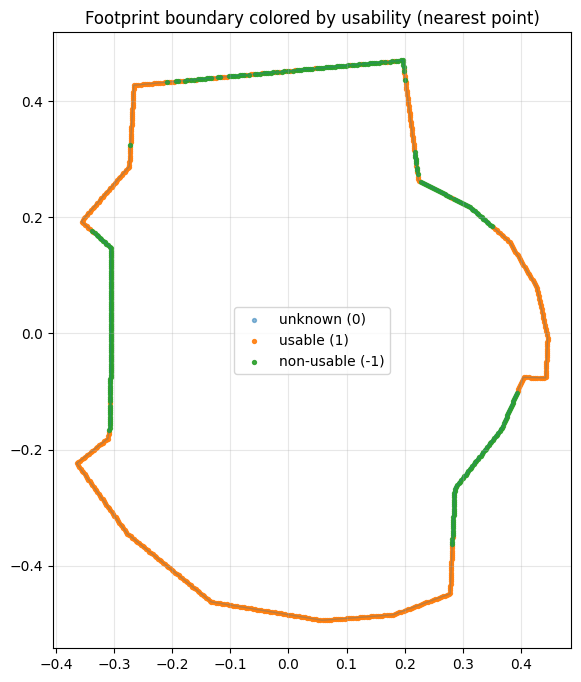

In [15]:
import matplotlib.pyplot as plt

mask_u = (b_usab == 1)
mask_n = (b_usab == -1)
mask_0 = (b_usab == 0)

fig, ax = plt.subplots(figsize=(8,8))

# show polygon outline faintly as reference
x0, y0 = poly_main.exterior.xy
ax.plot(x0, y0, linewidth=1, alpha=0.3)

# boundary samples colored by usability
ax.scatter(bxy[mask_0,0], bxy[mask_0,1], s=8, alpha=0.5, label="unknown (0)")
ax.scatter(bxy[mask_u,0], bxy[mask_u,1], s=8, alpha=0.9, label="usable (1)")
ax.scatter(bxy[mask_n,0], bxy[mask_n,1], s=8, alpha=0.9, label="non-usable (-1)")

ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title("Footprint boundary colored by usability (nearest point)")
plt.show()

In [16]:
import numpy as np
import os
from shapely.geometry import Polygon, MultiPolygon

# footprint must already exist here (Polygon or MultiPolygon)

def largest_polygon(geom):
    if isinstance(geom, Polygon):
        return geom
    if isinstance(geom, MultiPolygon):
        return max(list(geom.geoms), key=lambda p: p.area)
    raise TypeError(f"Unsupported type: {type(geom)}")

from shapely.geometry import LineString
def sample_boundary(poly: Polygon, n_samples=800):
    boundary = LineString(poly.exterior.coords)
    L = boundary.length
    dists = np.linspace(0.0, L, n_samples, endpoint=False)
    pts = [boundary.interpolate(float(d)) for d in dists]
    return np.array([[p.x, p.y] for p in pts], dtype=np.float32)

poly_main = largest_polygon(footprint)
boundary_xy = sample_boundary(poly_main, n_samples=1200)  # denser boundary is nicer

out_dir = "outputs_usability_probability"
os.makedirs(out_dir, exist_ok=True)
boundary_path = os.path.join(out_dir, "hpr_footprint_boundary_xy.npz")

np.savez_compressed(boundary_path, boundary_xy=boundary_xy)
print("Saved boundary:", boundary_path, "| shape:", boundary_xy.shape)

Saved boundary: outputs_usability_probability\hpr_footprint_boundary_xy.npz | shape: (1200, 2)
